In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)

In [2]:
train_df = pd.read_csv("../data/rus_news_data/train.csv")
val_df = pd.read_csv("../data/rus_news_data/val.csv")
test_df = pd.read_csv("../data/rus_news_data/test.csv")

In [3]:
X_train = train_df["text"]
y_train = train_df["rubric"]

X_val = val_df["text"]
y_val = val_df["rubric"]

X_test = test_df["text"]
y_test = test_df["rubric"]

In [4]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
)

In [5]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

In [6]:
print(X_train_tfidf.shape)

(3152, 43053)


In [8]:
clf = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
)

clf.fit(X_train_tfidf, y_train)

y_pred = clf.predict(X_test_tfidf)

In [9]:
print(
    classification_report(
        y_test,
        y_pred,
        digits=3,
    )
)

                   precision    recall  f1-score   support

   69-я параллель      0.500     0.250     0.333         4
      Бывший СССР      0.831     0.831     0.831        59
              Дом      0.923     0.632     0.750        19
         Из жизни      0.571     0.828     0.676        29
   Интернет и СМИ      0.655     0.613     0.633        31
         Культура      0.848     0.903     0.875        31
              Мир      0.818     0.750     0.783       108
  Наука и техника      0.700     0.903     0.789        31
       Нацпроекты      0.889     1.000     0.941         8
      Путешествия      0.821     0.821     0.821        28
           Россия      0.802     0.713     0.755       136
Силовые структуры      0.578     0.788     0.667        33
            Спорт      0.972     0.932     0.952        74
         Ценности      1.000     0.905     0.950        21
        Экономика      0.877     0.905     0.891        63

         accuracy                          0.801      

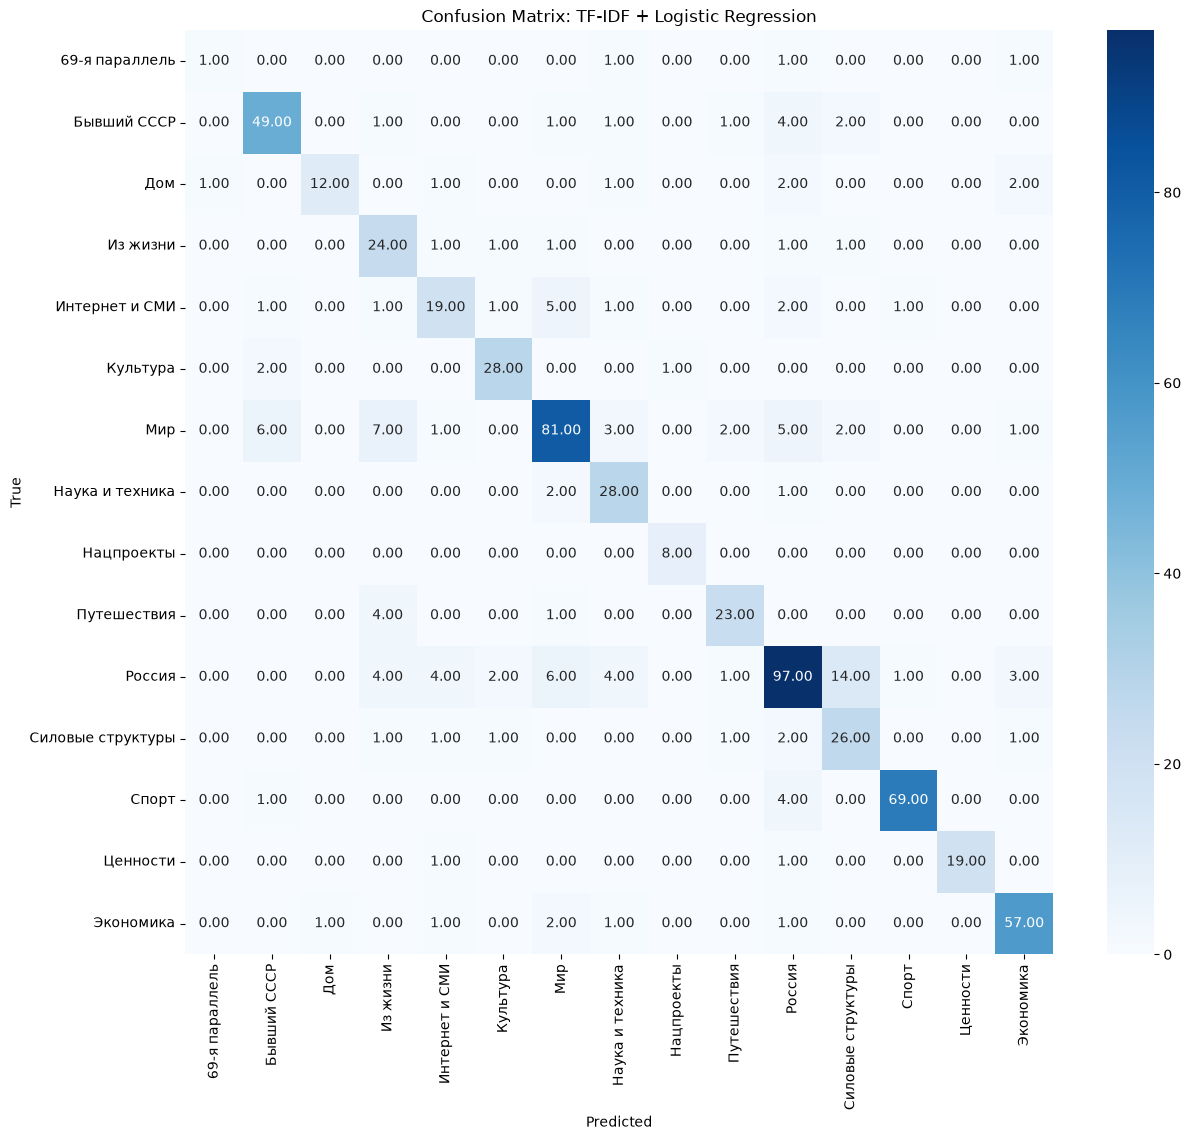

In [11]:
labels = sorted(y_test.unique())

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels,
)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix: TF-IDF + Logistic Regression")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

In [12]:
from sklearn.metrics import f1_score

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
)

weighted_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
)

print(f"Macro F1: {macro_f1:.3f}")
print(f"Weighted F1: {weighted_f1:.3f}")

Macro F1: 0.776
Weighted F1: 0.802
